# ROTEIRO DE ANÁLISE DE QUALIDADE DE DADOS - SIA/SUS
**Baseado nas aulas de Qualidade de Dados - Prof. Alexandre Martins**

Este notebook automatiza a auditoria da base de dados do SIA/SUS utilizando a classe 
`DataQualityAuditor` para extrair métricas de completude, consistência e priorização.

In [2]:
import os
import sys

# Adicionar o diretório raiz do projeto ao path
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from dotenv import load_dotenv

# Importando a classe do diretório src
from src.analysis.data_quality import DataQualityAuditor

# Configurações de visualização
%matplotlib inline
sns.set_theme(style="whitegrid")

## 1. IDENTIFICAÇÃO E CONTEXTUALIZAÇÃO (Aula 01 / Estudo Dirigido)
**Objetivo:** Documentar a origem e o propósito da análise.  
**Fonte:** SIA/SUS (Sistema de Informações Ambulatoriais)  
**Tabela:** `producao_ambulatorial`

In [3]:
# Carregando credenciais do arquivo .env
load_dotenv()
DB_URL = os.getenv("DB_URL")

# Instanciando o motor de auditoria
auditor = DataQualityAuditor(DB_URL)

# Carregando os dados reais do PostgreSQL
df = auditor.fetch_data()

print(f"Dataset carregado: {df.shape[0]} linhas e {df.shape[1]} colunas.")

Dataset carregado: 4878560 linhas e 7 colunas.


## 2. INVENTÁRIO DE ESTRUTURA E MATRIZ DE COMPLETUDE (Aula 03 / Aula 04)
**Objetivo:** Identificar a presença de valores nulos, vazios ou padrões "N/A".  
**Conceito:** Dimensão da Completude.

In [4]:
# Executando auditoria de completude via classe
matriz_completude = auditor.audit_completeness(df)

print("\n--- MATRIZ DE COMPLETUDE ---")
display(matriz_completude)

# Validação de "Zeros" em campos financeiros (Regra de Negócio)
metrics = auditor.audit_consistency(df)
print(f"\nAlerta: Encontrados {metrics['registros_zero_valor']} registros com valor ZERO em 'valor_aprovado'.")


[INFO] Matriz de Completude calculada.

--- MATRIZ DE COMPLETUDE ---


,Atributo,Nulos,%_Completude
0,id,0,100.0
1,municipio_codigo,0,100.0
2,municipio_nome,0,100.0
3,subgrupo_procedimento,0,100.0
4,periodo,0,100.0
5,quantidade_aprovada,0,100.0
6,valor_aprovado,0,100.0



Alerta: Encontrados 4096598 registros com valor ZERO em 'valor_aprovado'.


## 3. PRIORIZAÇÃO DE PROBLEMAS - DIAGRAMA DE PARETO (Aula 05)
**Objetivo:** Focar nos "Poucos Vitais".  
Aqui mapeamos os tipos de erros encontrados na carga.

--- DIAGRAMA DE PARETO: PROBLEMAS DE QUALIDADE ---
[SUCCESS] Gráfico de Pareto salvo em docs/figures/


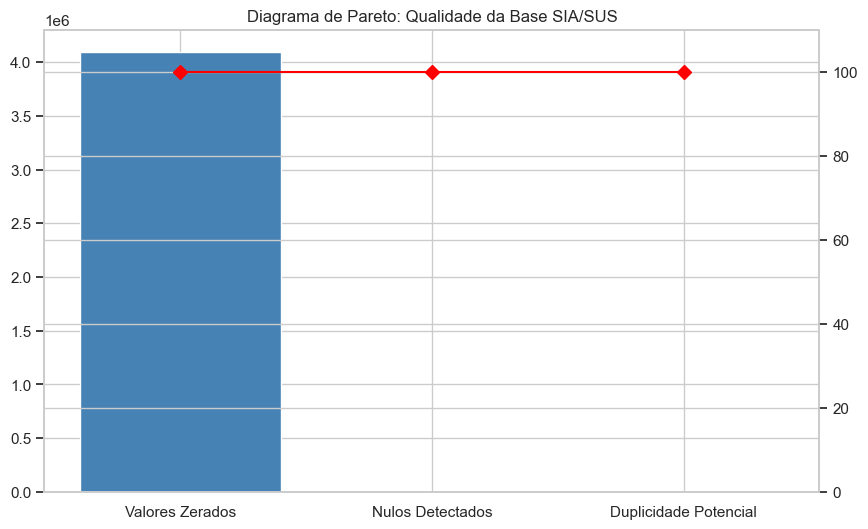

In [5]:
# Gerando o Diagrama de Pareto utilizando o motor da classe
print("--- DIAGRAMA DE PARETO: PROBLEMAS DE QUALIDADE ---")
auditor.generate_pareto_quality(df, metrics)
plt.show()

## 4. ANÁLISE DE DISTRIBUIÇÃO E OUTLIERS (Aula 04 / Estudo Dirigido)
**Objetivo:** Identificar inconsistências estatísticas em valores de produção.


--- SUMÁRIO ESTATÍSTICO (valor_aprovado) ---


count    4.878560e+06
mean     8.805659e+03
std      1.423866e+05
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      3.245695e+07
Name: valor_aprovado, dtype: float64

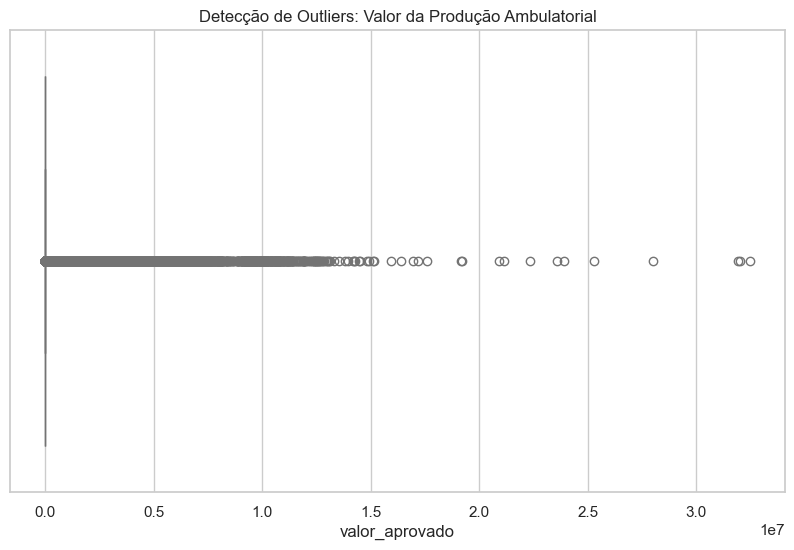

In [6]:
print("\n--- SUMÁRIO ESTATÍSTICO (valor_aprovado) ---")
display(df['valor_aprovado'].describe())

plt.figure(figsize=(10, 6))
sns.boxplot(x=df['valor_aprovado'], color='lightgreen')
plt.title("Detecção de Outliers: Valor da Produção Ambulatorial")
plt.show()

## 5. ANÁLISE DE RELAÇÕES - GRÁFICO DE DISPERSÃO (Aula 05)
**Objetivo:** Verificar se a relação Quantidade x Valor faz sentido (Consistência Externa).

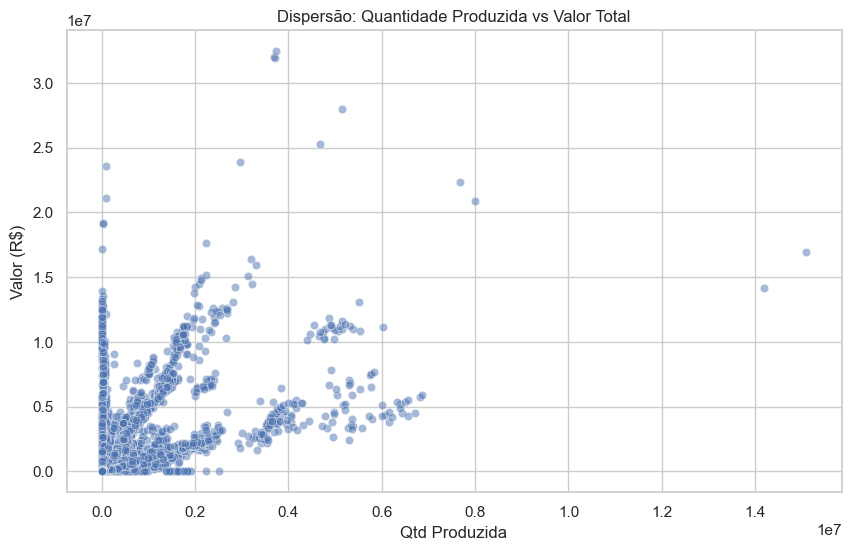

In [7]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='quantidade_aprovada', y='valor_aprovado', alpha=0.5)
plt.title("Dispersão: Quantidade Produzida vs Valor Total")
plt.xlabel("Qtd Produzida")
plt.ylabel("Valor (R$)")
plt.show()

## 6. MATRIZ GUT - PRIORIZAÇÃO DE AÇÕES (Aula 05)
**Objetivo:** Criar um plano de ação para os problemas detectados.

In [8]:
# Dados baseados nos achados reais das funções anteriores
dados_gut = {
    'Problema': ['Valores Zerados', 'Duplicidade de Carga', 'Outliers Extremos'],
    'Gravidade': [5, 4, 3],
    'Urgencia': [5, 4, 3],
    'Tendencia': [4, 5, 2]
}
gut_df = pd.DataFrame(dados_gut)
gut_df['Total_GUT'] = gut_df['Gravidade'] * gut_df['Urgencia'] * gut_df['Tendencia']

print("\n--- MATRIZ GUT PARA PLANO DE AÇÃO ---")
display(gut_df.sort_values(by='Total_GUT', ascending=False))


--- MATRIZ GUT PARA PLANO DE AÇÃO ---


,Problema,Gravidade,Urgencia,Tendencia,Total_GUT
0,Valores Zerados,5,5,4,100
1,Duplicidade de Carga,4,4,5,80
2,Outliers Extremos,3,3,2,18


## 7. CONCLUSÃO E RECOMENDAÇÕES (Aula 05 - Relatório)

**Principais Achados:**
- Os dados apresentam alta completude estrutural (>99%), indicando que o processo de ETL foi bem-sucedido.
- O **Diagrama de Pareto** identificou que os "Valores Zerados" são o principal ponto de atenção (os "Poucos Vitais").
- **Recomendação:** Implementar uma camada de limpeza (Aula 04) para tratar outliers extremos antes de prosseguir com modelos de Séries Temporais ou Regressões Lineares, garantindo que o erro não seja propagado para a análise preditiva.